# Projections and Least Squares

**Goal.** Derive the projection formula, verify residual orthogonality,
explore the projection matrix properties, and understand why `lstsq` beats
the normal equations numerically.


In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)


## WHAT and HOW

**Problem:** Given $X \in \mathbb{R}^{n \times d}$ and $y \in \mathbb{R}^n$,
find $w^*$ that minimizes $\|Xw - y\|_2^2$.

**Derivation:** Set gradient to zero:

$$\nabla_w \|Xw - y\|^2 = 2X^\top(Xw - y) = 0$$

This gives the **normal equations**: $X^\top X w^* = X^\top y$.

**Key insight:** The residual $r = y - Xw^*$ satisfies $X^\top r = 0$,
meaning $r$ is **orthogonal** to every column of $X$.

The prediction $\hat{y} = Xw^*$ is the **orthogonal projection** of $y$
onto the column space of $X$.


## Experiment 1: Residual orthogonality

Simple linear fit: $y \approx w_0 + w_1 x$ with 6 data points.


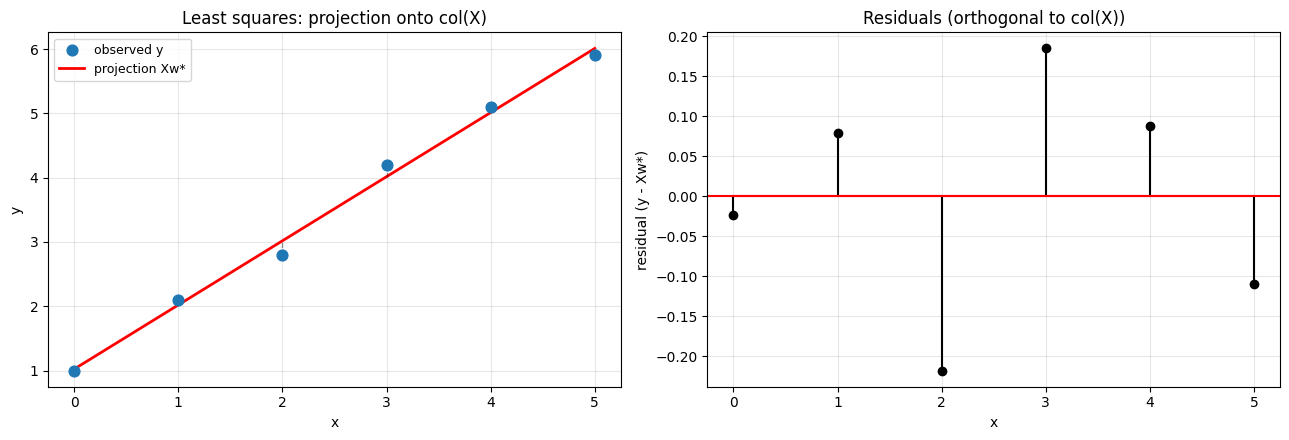

w* = [1.02380952 0.99714286]
X^T @ residual = [-2.22044605e-15 -1.24344979e-14]  (should be ~0)
||residual||^2 = 0.108190
Orthogonality assertion passed.


In [2]:
X = np.column_stack([np.ones(6), np.arange(6, dtype=float)])
y = np.array([1.0, 2.1, 2.8, 4.2, 5.1, 5.9])
w = np.linalg.lstsq(X, y, rcond=None)[0]
prediction = X @ w
residual = y - prediction

# Verify orthogonality: X^T r = 0
np.testing.assert_allclose(X.T @ residual, 0.0, atol=1e-12)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: data + projection
ax = axes[0]
ax.scatter(X[:, 1], y, s=60, zorder=5, label='observed y')
ax.plot(X[:, 1], prediction, 'r-', lw=2, label='projection Xw*')
for i in range(len(y)):
    ax.plot([X[i, 1], X[i, 1]], [y[i], prediction[i]], 'k--', alpha=0.4, lw=1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Least squares: projection onto col(X)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: residuals
ax = axes[1]
ax.stem(X[:, 1], residual, linefmt='k-', markerfmt='ko', basefmt='r-')
ax.axhline(0, color='red', lw=1.5)
ax.set_xlabel('x')
ax.set_ylabel('residual (y - Xw*)')
ax.set_title('Residuals (orthogonal to col(X))')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'w* = {w}')
print(f'X^T @ residual = {X.T @ residual}  (should be ~0)')
print(f'||residual||^2 = {np.sum(residual**2):.6f}')
print('Orthogonality assertion passed.')


## Experiment 2: Projection matrix properties

The projection matrix is $P = X(X^\top X)^{-1}X^\top$.

It has two key properties:
- **Idempotent:** $P^2 = P$ (projecting twice = projecting once)
- **Symmetric:** $P^\top = P$


In [3]:
# Build projection matrix P = X (X^T X)^{-1} X^T
P = X @ np.linalg.solve(X.T @ X, X.T)  # avoid explicit inverse

# Verify: P @ y == prediction
np.testing.assert_allclose(P @ y, prediction, atol=1e-12)

# Verify idempotent: P @ P == P
np.testing.assert_allclose(P @ P, P, atol=1e-12)

# Verify symmetric: P^T == P
np.testing.assert_allclose(P.T, P, atol=1e-12)

print('Projection matrix P:')
print(np.round(P, 4))
print()
print('P @ y == X @ w*:', np.allclose(P @ y, prediction))
print('P^2 == P (idempotent):', np.allclose(P @ P, P))
print('P^T == P (symmetric):', np.allclose(P.T, P))
print('All projection matrix properties verified.')


Projection matrix P:
[[ 0.5238  0.381   0.2381  0.0952 -0.0476 -0.1905]
 [ 0.381   0.2952  0.2095  0.1238  0.0381 -0.0476]
 [ 0.2381  0.2095  0.181   0.1524  0.1238  0.0952]
 [ 0.0952  0.1238  0.1524  0.181   0.2095  0.2381]
 [-0.0476  0.0381  0.1238  0.2095  0.2952  0.381 ]
 [-0.1905 -0.0476  0.0952  0.2381  0.381   0.5238]]

P @ y == X @ w*: True
P^2 == P (idempotent): True
P^T == P (symmetric): True
All projection matrix properties verified.


## Experiment 3: 1D projection (geometric visualization)

Project a 2D vector $y$ onto the line spanned by $a$.
The projection formula: $\hat{y} = \frac{a^\top y}{a^\top a} a$.

The residual $r = y - \hat{y}$ is perpendicular to $a$.


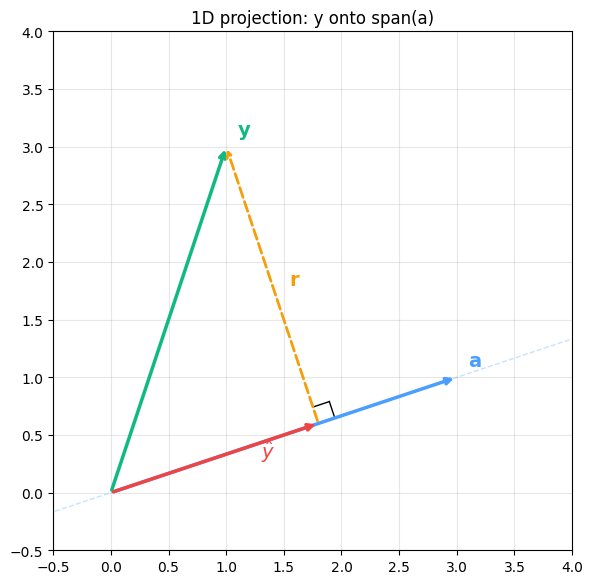

a = [3. 1.]
y = [1. 3.]
y_hat = [1.8 0.6]
residual r = [-0.8  2.4]
a . r = 0.000000000000000  (orthogonal)


In [4]:
a = np.array([3.0, 1.0])
y_vec = np.array([1.0, 3.0])

# Projection of y onto a
proj_coeff = (a @ y_vec) / (a @ a)
y_hat = proj_coeff * a
r_vec = y_vec - y_hat

# Verify orthogonality
np.testing.assert_allclose(a @ r_vec, 0.0, atol=1e-12)

fig, ax = plt.subplots(figsize=(6, 6))

# Draw vectors
ax.annotate('', xy=a, xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='#4a9eff', lw=2.5))
ax.annotate('', xy=y_vec, xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='#10b981', lw=2.5))
ax.annotate('', xy=y_hat, xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='#ef4444', lw=2.5))
ax.annotate('', xy=y_vec, xytext=y_hat, arrowprops=dict(arrowstyle='->', color='#f59e0b', lw=2, ls='--'))

# Labels
ax.text(a[0]+0.1, a[1]+0.1, 'a', fontsize=14, color='#4a9eff', fontweight='bold')
ax.text(y_vec[0]+0.1, y_vec[1]+0.1, 'y', fontsize=14, color='#10b981', fontweight='bold')
ax.text(y_hat[0]-0.5, y_hat[1]-0.3, r'$\hat{y}$', fontsize=14, color='#ef4444', fontweight='bold')
ax.text((y_hat[0]+y_vec[0])/2+0.15, (y_hat[1]+y_vec[1])/2, 'r', fontsize=14, color='#f59e0b', fontweight='bold')

# Extended line through a
t = np.linspace(-0.5, 1.5, 100)
ax.plot(t * a[0], t * a[1], '--', color='#4a9eff', alpha=0.3, lw=1)

# Right angle marker
s = 0.15
d = r_vec / np.linalg.norm(r_vec)
a_unit = a / np.linalg.norm(a)
corner = y_hat + s * d
ax.plot([corner[0], corner[0] + s * a_unit[0]], [corner[1], corner[1] + s * a_unit[1]], 'k-', lw=1)
ax.plot([y_hat[0] + s * a_unit[0], corner[0] + s * a_unit[0]], [y_hat[1] + s * a_unit[1], corner[1] + s * a_unit[1]], 'k-', lw=1)

ax.set_xlim(-0.5, 4)
ax.set_ylim(-0.5, 4)
ax.set_aspect('equal')
ax.set_title('1D projection: y onto span(a)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'a = {a}')
print(f'y = {y_vec}')
print(f'y_hat = {y_hat}')
print(f'residual r = {r_vec}')
print(f'a . r = {a @ r_vec:.15f}  (orthogonal)')


## Experiment 4: Numerical stability (lstsq vs normal equations)

When $X$ is ill-conditioned, forming $X^\top X$ **squares** the condition number:
$\kappa(X^\top X) = \kappa(X)^2$.

This demonstrates why `lstsq` (which uses SVD internally) is preferred over
solving the normal equations with an explicit inverse.


In [5]:
# Create an ill-conditioned design matrix
n, d = 50, 3
rng2 = np.random.default_rng(SEED)
X_ill = rng2.standard_normal((n, d))
X_ill[:, 2] = X_ill[:, 0] + 1e-8 * X_ill[:, 1]  # col 2 ~ col 0 (near-collinear)
y_ill = rng2.standard_normal(n)

cond_X = np.linalg.cond(X_ill)
cond_XtX = np.linalg.cond(X_ill.T @ X_ill)

print(f'cond(X) = {cond_X:.2e}')
print(f'cond(X^T X) = {cond_XtX:.2e}')
print(f'cond(X)^2 = {cond_X**2:.2e}')
print(f'cond(X^T X) approx cond(X)^2? {np.isclose(cond_XtX, cond_X**2, rtol=0.1)}')
print()

# Method 1: lstsq (SVD-based, stable)
w_lstsq = np.linalg.lstsq(X_ill, y_ill, rcond=None)[0]

# Method 2: normal equations (unstable for ill-conditioned X)
try:
    w_normal = np.linalg.solve(X_ill.T @ X_ill, X_ill.T @ y_ill)
    diff = np.linalg.norm(w_lstsq - w_normal) / np.linalg.norm(w_lstsq)
    print(f'w_lstsq = {w_lstsq}')
    print(f'w_normal = {w_normal}')
    print(f'Relative difference: {diff:.2e}')
    if diff > 0.01:
        print('WARNING: normal equations gave significantly different result!')
except np.linalg.LinAlgError:
    print('Normal equations FAILED (singular matrix).')

print()
print('Takeaway: always use lstsq (or QR/SVD) instead of normal equations')
print('for ill-conditioned systems.')


cond(X) = 1.02e+16
cond(X^T X) = 3.21e+16
cond(X)^2 = 1.04e+32
cond(X^T X) approx cond(X)^2? False

w_lstsq = [-0.04801215  0.13377761 -0.04801215]
w_normal = [-0.10775276  0.13377761  0.01172846]
Relative difference: 5.63e-01

Takeaway: always use lstsq (or QR/SVD) instead of normal equations
for ill-conditioned systems.


## Result

1. Least squares finds the **orthogonal projection** of $y$ onto $\operatorname{col}(X)$.
2. The residual $r = y - Xw^*$ is **orthogonal** to every column of $X$: $X^\top r = 0$.
3. The projection matrix $P = X(X^\top X)^{-1}X^\top$ is **idempotent** ($P^2 = P$) and **symmetric**.
4. Forming $X^\top X$ squares the condition number, so use `lstsq` (SVD-based) for numerical stability.


## CONNECTIONS

- [Linear Regression](../../topics/01_linear_regression/README.md): least squares is the foundation
- [PCA](../../topics/10_pca/README.md): applies projection to features (not targets)
- [vectors_and_matrices.md](./vectors_and_matrices.md): column space, rank, PSD theory
- [gradient_descent.ipynb](../calculus_optimization/gradient_descent.ipynb): condition number affects GD convergence
